<a href="https://colab.research.google.com/github/pushkarkn/Quant_GAN/blob/main/PBL_TimeGAN_AutoGen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas numpy matplotlib seaborn tqdm

In [ ]:
import yfinance as yf, pandas as pd
df = yf.download("SPY", start="2015-01-01", end="2023-12-31", interval="1d")[["Open","High","Low","Close","Volume"]]
df.to_csv("spy_real.csv")
print(df.shape)

/tmp/ipython-input-1091083389.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", start="2015-01-01", end="2023-12-31", interval="1d")[["Open","High","Low","Close","Volume"]]
[*********************100%***********************]  1 of 1 completed

(2264, 5)


In [ ]:
import numpy as np

df = pd.read_csv("spy_real.csv", index_col=0, parse_dates=True, skiprows=[1, 2])
df['ma20']   = df['Close'].rolling(20).mean()
df['vol20']  = df['Close'].pct_change().rolling(20).std()
df['rate']   = df['Close'].pct_change().shift(1)

df.dropna(inplace=True)

df.to_csv("spy_clean.csv")

# EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import io

sns.set(style="whitegrid")

file_name = 'spy_clean.csv'

try:

    df = pd.read_csv(file_name, index_col=0, parse_dates=True)
    df.index.name = 'Date'

    print(f"Successfully loaded '{file_name}'.")

    print("\n--- DataFrame Head ---")
    print(df.head())

    print("\n--- DataFrame Info ---")
    df.info()

    print("\n--- Descriptive Statistics ---")
    print(df.describe())

except FileNotFoundError:
    print(f"Error: File '{file_name}' not found. Make sure the file exists.")
except Exception as e:
    print(f"An error occurred while loading the data: {e}")

Successfully loaded 'spy_clean.csv'.

--- DataFrame Head ---
                  Open        High         Low       Close     Volume  \
Date                                                                    
2015-02-02  166.612957  168.262010  164.788999  168.170395  163107000   
2015-02-03  169.069857  170.610647  168.695075  170.602310  124212900   
2015-02-04  169.836129  171.052105  169.494655  169.952728  134306700   
2015-02-05  170.618925  171.818240  170.543971  171.668320   97953200   
2015-02-06  172.034830  172.601179  170.668946  171.193649  125672000   

                  ma20     vol20      rate  
Date                                        
2015-02-02  168.575970  0.011050 -0.012575  
2015-02-03  168.705895  0.010766  0.012384  
2015-02-04  168.882465  0.010557  0.014461  
2015-02-05  169.041124  0.010435 -0.003808  
2015-02-06  169.026550  0.009682  0.010095  

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2244 entries, 2015-02-02 to 2023-12

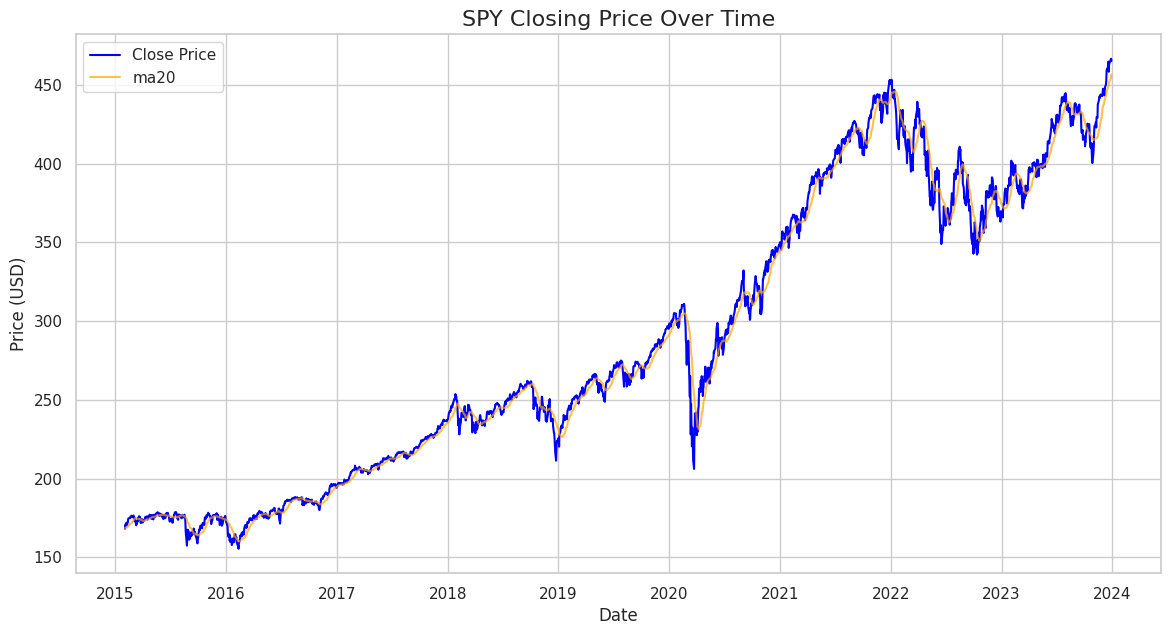

In [ ]:
if 'Close' in df.columns:
    plt.figure(figsize=(14, 7))

    plt.plot(df.index, df['Close'], label='Close Price', color='blue')

    if 'ma20' in df.columns:
        plt.plot(df.index, df['ma20'], label='ma20', color='orange', alpha=0.7)

    plt.title('SPY Closing Price Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Cannot generate Price plot: 'Close' column not found.")

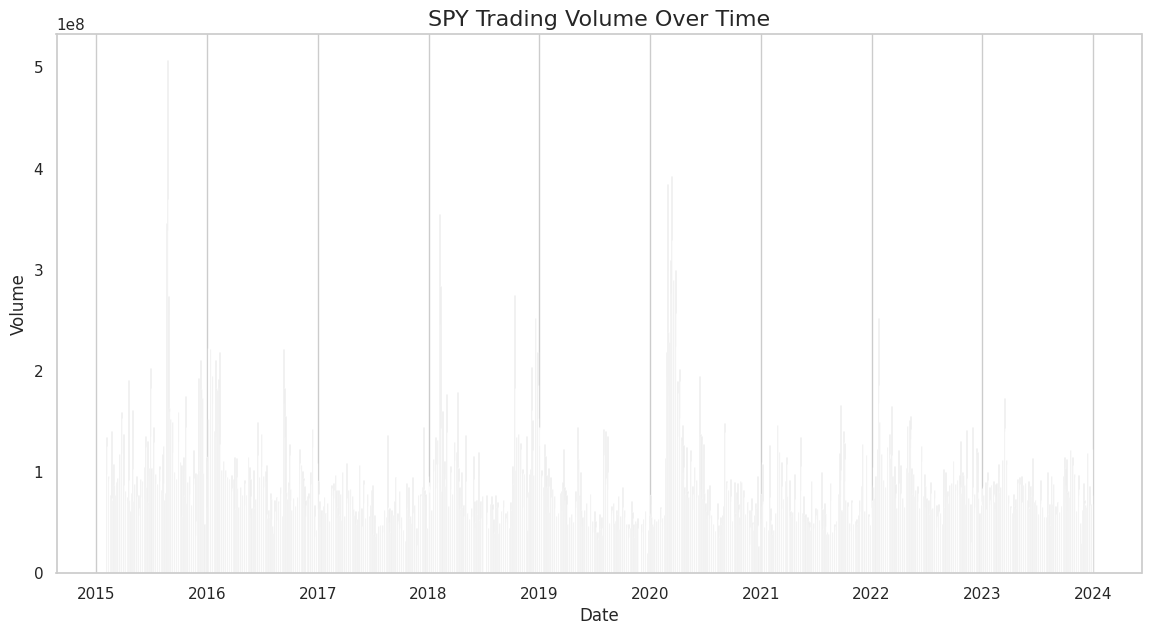

In [ ]:
if 'Volume' in df.columns:
    plt.figure(figsize=(14, 7))
    plt.bar(df.index, df['Volume'], color='gray', alpha=0.7, width=1.0)
    plt.title('SPY Trading Volume Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Volume', fontsize=12)
    plt.grid(axis='y')
    plt.show()
else:
    print("Cannot generate Volume plot: 'Volume' column not found.")

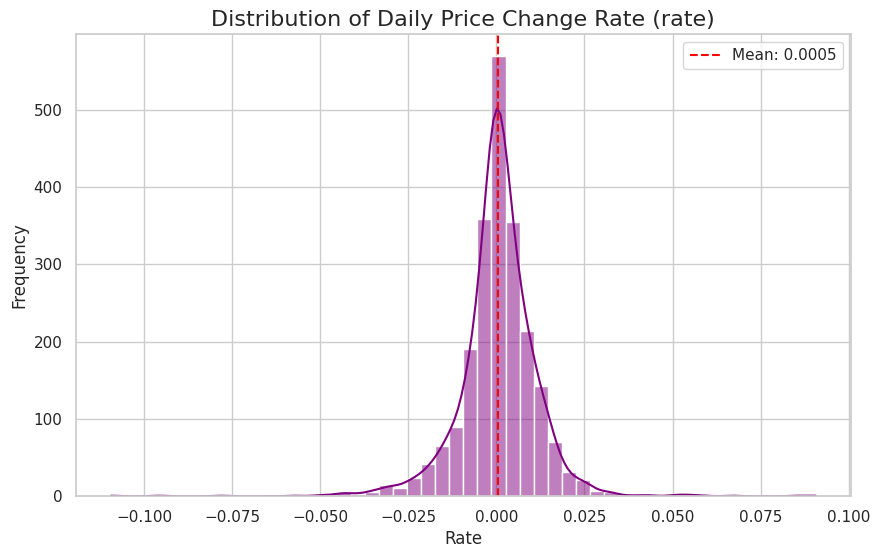

In [ ]:
if 'rate' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['rate'], kde=True, bins=50, color='purple')
    plt.title('Distribution of Daily Price Change Rate (rate)', fontsize=16)
    plt.xlabel('Rate', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.axvline(df['rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["rate"].mean():.4f}')
    plt.legend()
    plt.show()
else:
    print("Cannot generate Rate Distribution plot: 'rate' column not found.")

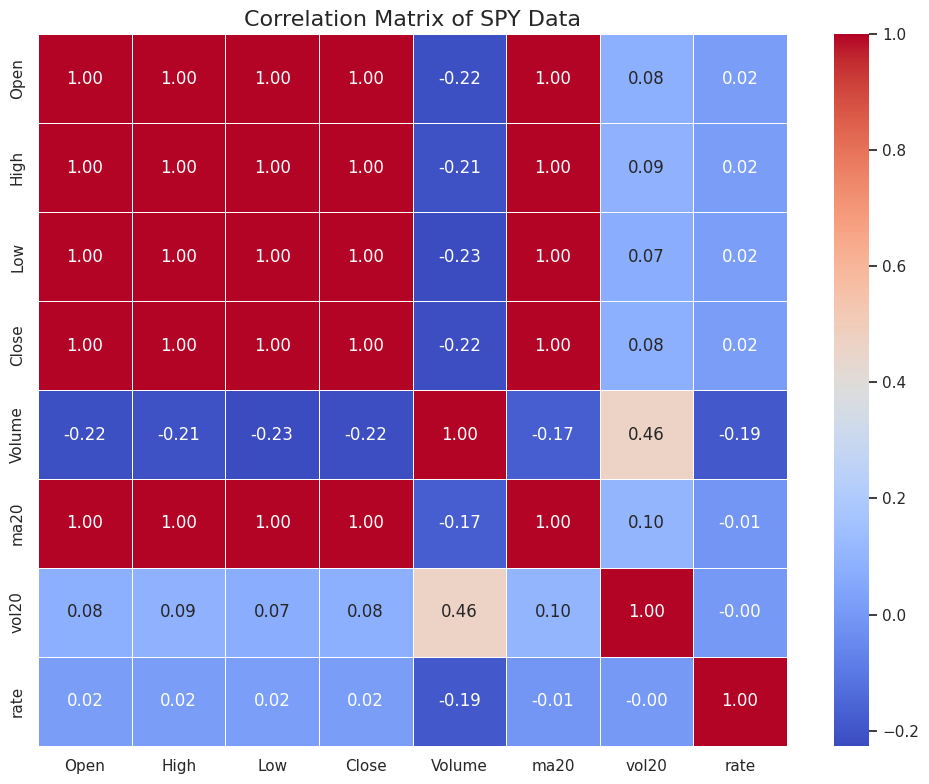

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of SPY Data', fontsize=16)
plt.tight_layout()
plt.show()

Generating pairplot for: Close, High, Low, Volume, rate


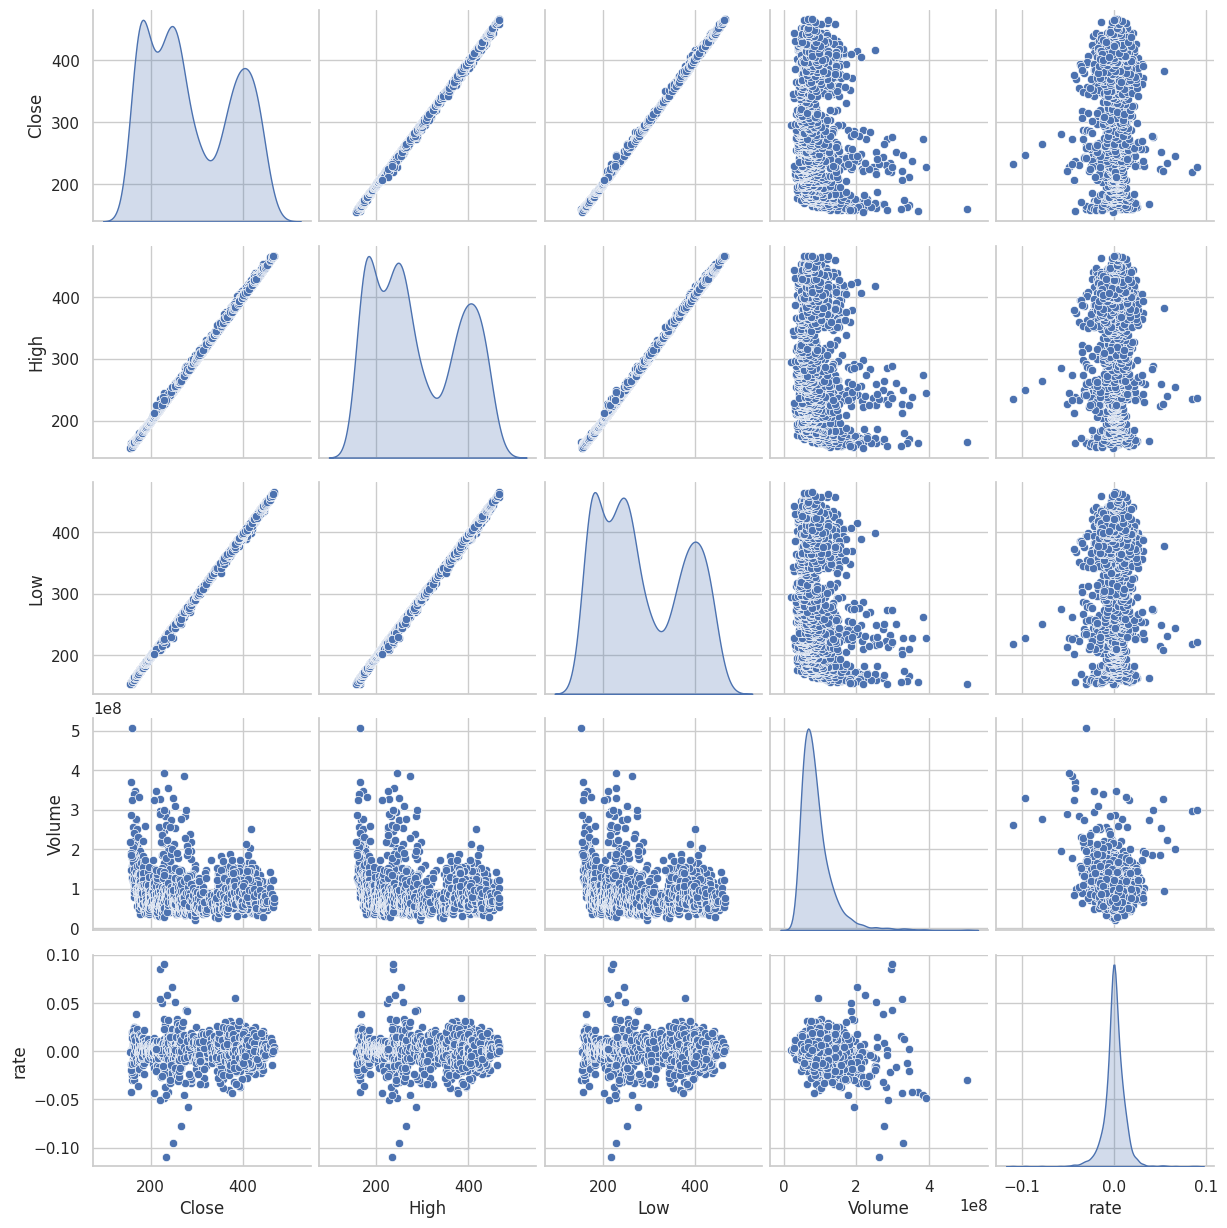

In [ ]:
pairplot_cols = ['Close', 'High', 'Low', 'Volume', 'rate']

valid_pairplot_cols = [col for col in pairplot_cols if col in df.columns]

if valid_pairplot_cols:
    print(f"Generating pairplot for: {', '.join(valid_pairplot_cols)}")
    sns.pairplot(df[valid_pairplot_cols], diag_kind='kde')
    plt.show()
else:
    print("Skipping pairplot: None of the specified columns (Close, High, Low, Volume, rate) were found.")

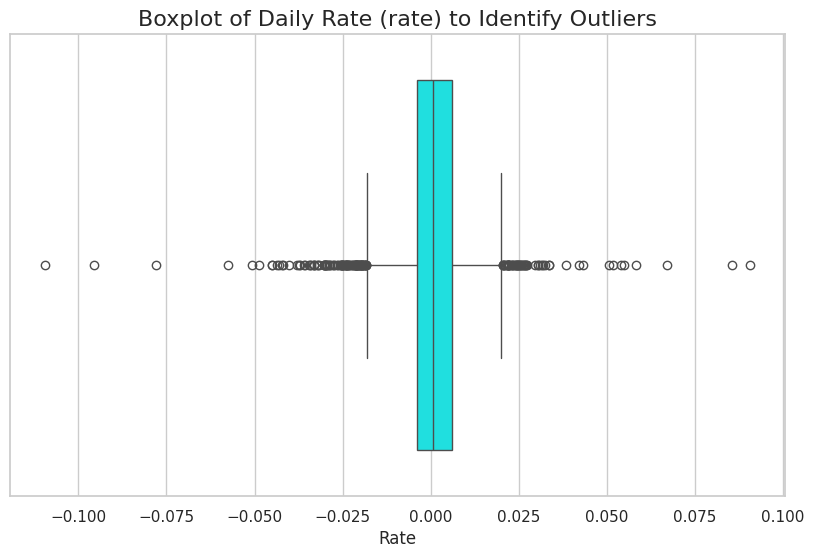

In [ ]:
if 'rate' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df['rate'], color='cyan')
    plt.title('Boxplot of Daily Rate (rate) to Identify Outliers', fontsize=16)
    plt.xlabel('Rate', fontsize=12)
    plt.show()
else:
    print("Cannot generate Rate Boxplot: 'rate' column not found.")

# GAN Generation

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, MeanSquaredError
from sklearn.preprocessing import MinMaxScaler
import warnings

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')

SEQ_LEN = 24
HIDDEN_DIM = 24
NOISE_DIM = 24
BATCH_SIZE = 128
EPOCHS = 100

file_name = 'spy_clean.csv'

try:

    df = pd.read_csv(file_name, index_col=0, parse_dates=True)

    print(f"Successfully loaded '{file_name}'.")

    features = ['Open', 'High', 'Low', 'Close', 'Volume']
    data = df[features].values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    N_FEATURES = data.shape[1]

    def create_sequences(data, seq_len):
        sequences = []
        for i in range(len(data) - seq_len + 1):
            sequences.append(data[i:i+seq_len])
        return np.array(sequences)

    sequences = create_sequences(data_scaled, SEQ_LEN)
    print(f"Total sequences: {len(sequences)}")

    def create_tf_dataset(data):
        return tf.data.Dataset.from_tensor_slices(data).shuffle(
            buffer_size=len(data)
        ).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    real_data_loader = create_tf_dataset(sequences.astype(np.float32))

    def create_noise_dataset(n_samples, n_features, seq_len):
        return tf.data.Dataset.from_generator(
            lambda: (tf.random.normal([seq_len, n_features]) for _ in range(n_samples)),
            output_signature=tf.TensorSpec(shape=(seq_len, n_features), dtype=tf.float32)
        ).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

    noise_data_loader = create_noise_dataset(len(sequences), NOISE_DIM, SEQ_LEN)

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found.")
    print("Please make sure it's in the root directory, or update the 'file_name' path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded 'spy_clean.csv'.
Total sequences: 2221


In [ ]:
def build_embedder(seq_len, n_features, hidden_dim):
    inp = Input(shape=(seq_len, n_features))
    x = LSTM(hidden_dim, return_sequences=True)(inp)
    model = Model(inp, x, name='embedder')
    return model

def build_recovery(seq_len, n_features, hidden_dim):
    inp = Input(shape=(seq_len, hidden_dim))
    x = LSTM(hidden_dim, return_sequences=True)(inp)
    x = TimeDistributed(Dense(n_features))(x)
    model = Model(inp, x, name='recovery')
    return model

def build_generator(seq_len, noise_dim, hidden_dim):
    inp = Input(shape=(seq_len, noise_dim))
    x = LSTM(hidden_dim, return_sequences=True)(inp)
    model = Model(inp, x, name='generator')
    return model

def build_discriminator(seq_len, hidden_dim):
    inp = Input(shape=(seq_len, hidden_dim))
    x = LSTM(hidden_dim, return_sequences=True)(inp)
    x = TimeDistributed(Dense(1, activation='sigmoid'))(x)
    model = Model(inp, x, name='discriminator')
    return model

embedder = build_embedder(SEQ_LEN, N_FEATURES, HIDDEN_DIM)
recovery = build_recovery(SEQ_LEN, N_FEATURES, HIDDEN_DIM)
generator = build_generator(SEQ_LEN, NOISE_DIM, HIDDEN_DIM)
discriminator = build_discriminator(SEQ_LEN, HIDDEN_DIM)

autoencoder_optimizer = Adam(learning_rate=1e-3)
supervisor_optimizer = Adam(learning_rate=1e-3)
generator_optimizer = Adam(learning_rate=1e-3)
discriminator_optimizer = Adam(learning_rate=1e-3)

bce = BinaryCrossentropy()
mse = MeanSquaredError()

In [ ]:
@tf.function
def train_autoencoder(X_batch):
    with tf.GradientTape() as tape:
        H = embedder(X_batch)
        X_hat = recovery(H)
        recon_loss = mse(X_batch, X_hat)

    trainable_vars = embedder.trainable_variables + recovery.trainable_variables
    grads = tape.gradient(recon_loss, trainable_vars)
    autoencoder_optimizer.apply_gradients(zip(grads, trainable_vars))
    return recon_loss

@tf.function
def train_supervisor(X_batch, Z_batch):
    with tf.GradientTape() as tape:
        H = embedder(X_batch)
        E_hat = generator(Z_batch)
        supervisor_loss = mse(H, E_hat)

    trainable_vars = generator.trainable_variables
    grads = tape.gradient(supervisor_loss, trainable_vars)
    supervisor_optimizer.apply_gradients(zip(grads, trainable_vars))
    return supervisor_loss

@tf.function
def train_adversarial(X_batch, Z_batch):

    with tf.GradientTape() as tape:
        H = embedder(X_batch)
        E_hat = generator(Z_batch)

        Y_real = discriminator(H)
        Y_fake = discriminator(E_hat)

        d_loss_real = bce(tf.ones_like(Y_real), Y_real)
        d_loss_fake = bce(tf.zeros_like(Y_fake), Y_fake)
        d_loss = d_loss_real + d_loss_fake

    trainable_vars = discriminator.trainable_variables
    grads = tape.gradient(d_loss, trainable_vars)
    discriminator_optimizer.apply_gradients(zip(grads, trainable_vars))

    with tf.GradientTape() as tape:
        E_hat = generator(Z_batch)
        Y_fooled = discriminator(E_hat)
        g_loss = bce(tf.ones_like(Y_fooled), Y_fooled)

    trainable_vars = generator.trainable_variables
    grads = tape.gradient(g_loss, trainable_vars)
    generator_optimizer.apply_gradients(zip(grads, trainable_vars))

    return d_loss, g_loss

In [ ]:
from tqdm import tqdm

print("Starting TimeGAN training...")

for epoch in range(EPOCHS):
    pbar = tqdm(zip(real_data_loader, noise_data_loader), total=len(real_data_loader))
    pbar.set_description(f"Epoch {epoch+1}/{EPOCHS}")

    ae_loss_epoch, sup_loss_epoch, d_loss_epoch, g_loss_epoch = 0, 0, 0, 0

    for X_batch, Z_batch in pbar:

        ae_loss = train_autoencoder(X_batch)

        sup_loss = train_supervisor(X_batch, Z_batch)

        d_loss, g_loss = train_adversarial(X_batch, Z_batch)

        ae_loss_epoch += ae_loss.numpy()
        sup_loss_epoch += sup_loss.numpy()
        d_loss_epoch += d_loss.numpy()
        g_loss_epoch += g_loss.numpy()

        pbar.set_postfix(
            AE_Loss=ae_loss.numpy(),
            S_Loss=sup_loss.numpy(),
            D_Loss=d_loss.numpy(),
            G_Loss=g_loss.numpy()
        )

print("\n--- Training Complete ---")

Starting TimeGAN training...


Epoch 100/100: 100%|██████████| 17/17 [00:05<00:00,  2.84it/s, AE_Loss=6.18e-5, D_Loss=0.803, G_Loss=1.36, S_Loss=0.013]


--- Training Complete ---


In [ ]:
model_filename = 'timegan_generator.keras'
generator.save(model_filename)

print(f"\nGenerator model saved as '{model_filename}'")


Generator model saved as 'timegan_generator.keras'


# Model Eval Graphs

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

num_samples_to_gen = len(sequences)

feature_to_plot = 3
feature_name = features[feature_to_plot]

print("Generating synthetic data...")

Z_samples = np.random.normal(size=(num_samples_to_gen, SEQ_LEN, NOISE_DIM))

E_hat_samples = generator.predict(Z_samples.astype(np.float32), verbose=0)

X_hat_samples = recovery.predict(E_hat_samples, verbose=0)

print("Un-scaling data for plotting...")

synthetic_data_flat = X_hat_samples.reshape(-1, N_FEATURES)
synthetic_data_unscaled_flat = scaler.inverse_transform(synthetic_data_flat)

synthetic_data_unscaled = synthetic_data_unscaled_flat.reshape(num_samples_to_gen, SEQ_LEN, N_FEATURES)

real_data_flat = sequences.reshape(-1, N_FEATURES)
real_data_unscaled_flat = scaler.inverse_transform(real_data_flat)

real_data_unscaled = real_data_unscaled_flat.reshape(len(sequences), SEQ_LEN, N_FEATURES)

print("Data preparation complete.")

Generating synthetic data...
Un-scaling data for plotting...
Data preparation complete.


Plotting Time-Series Overlay for: Close


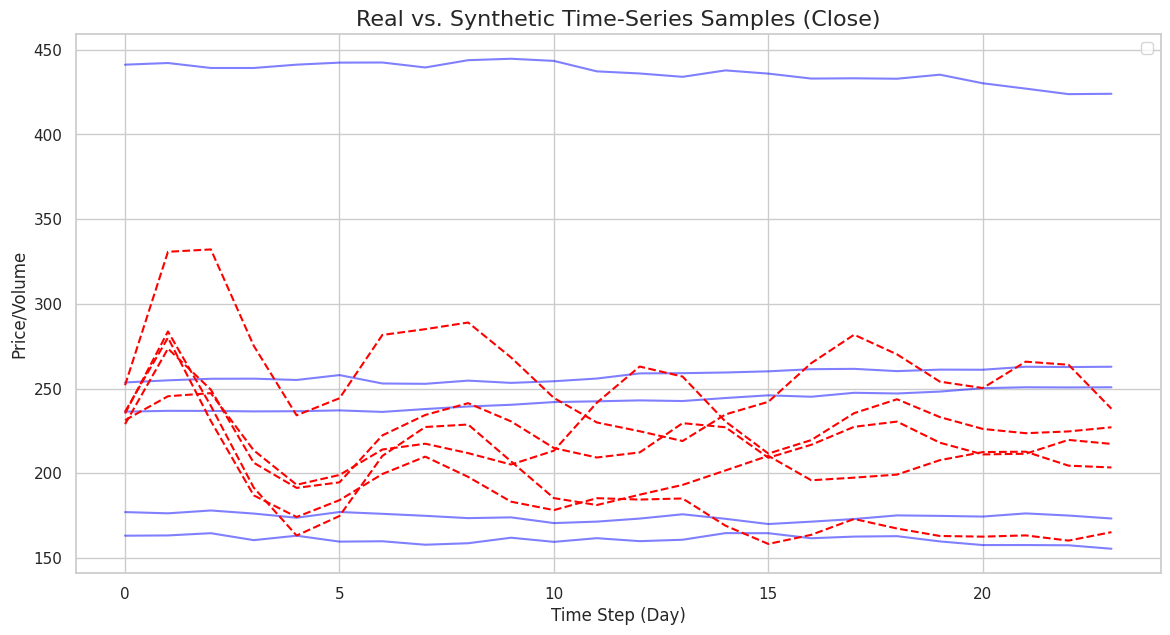

In [ ]:
print(f"Plotting Time-Series Overlay for: {feature_name}")

num_examples = 5

plt.figure(figsize=(14, 7))

for i in np.random.randint(0, len(real_data_unscaled), num_examples):
    plt.plot(
        real_data_unscaled[i, :, feature_to_plot],
        label='Real' if i == np.random.randint(0, len(real_data_unscaled), num_examples)[0] else None,
        color='blue',
        alpha=0.5
    )

for i in np.random.randint(0, len(synthetic_data_unscaled), num_examples):
    plt.plot(
        synthetic_data_unscaled[i, :, feature_to_plot],
        label='Synthetic' if i == np.random.randint(0, len(synthetic_data_unscaled), num_examples)[0] else None,
        color='red',
        linestyle='--'
    )

plt.title(f'Real vs. Synthetic Time-Series Samples ({feature_name})', fontsize=16)
plt.xlabel('Time Step (Day)', fontsize=12)
plt.ylabel('Price/Volume', fontsize=12)
plt.legend()
plt.show()

Plotting Distribution Comparison for: Close


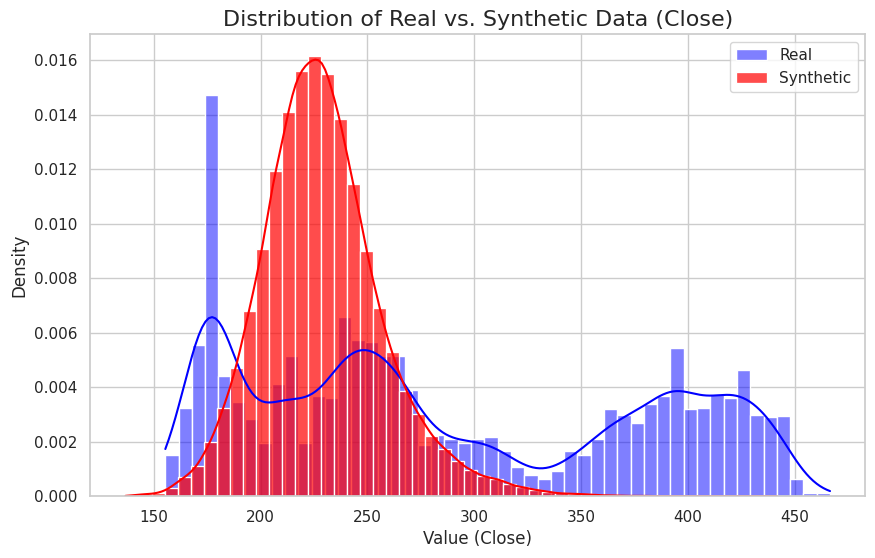

In [ ]:
print(f"Plotting Distribution Comparison for: {feature_name}")

plt.figure(figsize=(10, 6))

sns.histplot(
    real_data_unscaled_flat[:, feature_to_plot],
    label='Real',
    kde=True,
    color='blue',
    stat='density',
    bins=50
)

sns.histplot(
    synthetic_data_unscaled_flat[:, feature_to_plot],
    label='Synthetic',
    kde=True,
    color='red',
    stat='density',
    bins=50,
    alpha=0.7
)

plt.title(f'Distribution of Real vs. Synthetic Data ({feature_name})', fontsize=16)
plt.xlabel(f'Value ({feature_name})', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

Plotting Correlation Heatmaps...


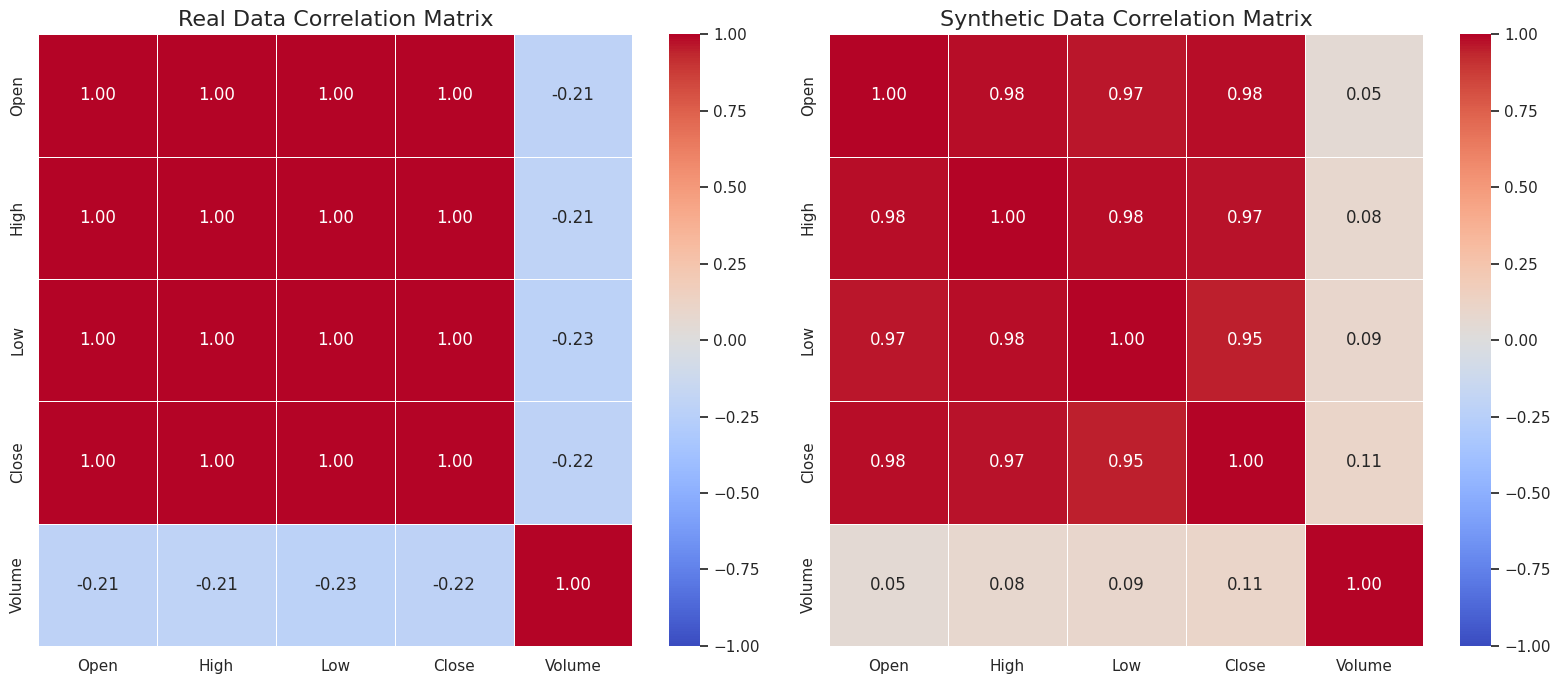

In [ ]:
print("Plotting Correlation Heatmaps...")

# Create DataFrames for correlation calculation
real_df = pd.DataFrame(real_data_unscaled_flat, columns=features)
synth_df = pd.DataFrame(synthetic_data_unscaled_flat, columns=features)

# Calculate correlation matrices
real_corr = real_df.corr()
synth_corr = synth_df.corr()

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Real Data Heatmap
sns.heatmap(real_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Real Data Correlation Matrix', fontsize=16)

# Synthetic Data Heatmap
sns.heatmap(synth_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Synthetic Data Correlation Matrix', fontsize=16)

plt.tight_layout()
plt.show()